In [1]:
import json
import os
import urllib
def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    
    with open(file_path, "r") as file:
        data = json.load(file)
    return data


file_path = "instruction-data.json"
url = (
 "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
 "/main/ch07/01_main-chapter-code/instruction-data.json"
)
data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [2]:
print("Example entry:\n", data[50])

Example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [3]:
print("Another example entry:\n", data[999])

Another example entry:
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


In [4]:
# Alpaca formatting
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

In [5]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [6]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [7]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## Batching data

In [8]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(tokenizer.encode(full_text))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [9]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [10]:
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst = []
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [11]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (
 inputs_1,
 inputs_2,
 inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [12]:
def custom_collate_draft_2(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [13]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [14]:
def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [15]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [16]:
### Why we need -100
### Example of loss calculation
logits_1 = torch.tensor(
 [[-1.0, 1.0],
 [-0.5, 1.5]]
)
targets_1 = torch.tensor([0, 1]) # Correct token indices to generate
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [17]:
logits_2 = torch.tensor(
 [[-1.0, 1.0],
 [-0.5, 1.5],
 [-0.5, 1.5]]
)
targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [18]:
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)  # Pytorch ignores -100 values by default
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


## Creating data loaders

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.backends.mps.is_available():
# device = torch.device("mps")"
print("Device:", device)

Device: cuda


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


In [20]:
from functools import partial
customized_collate_fn = partial(
 custom_collate_fn,
 device=device,
 allowed_max_length=1024
)

In [21]:
from torch.utils.data import DataLoader
num_workers = 0
batch_size = 8
torch.manual_seed(123)
train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [22]:
print("Train loader:")
i = 5
for inputs, targets in train_loader:
 print(inputs.shape, targets.shape)
 i -= 1
 if i == 0:
     break

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])


### Loading a pretrained LLM

In [23]:
from gpt_download import download_and_load_gpt2
import torch
import torch.nn as nn

# From ch04
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

# Copied from ch03 : MultiheadAttentionV2
class MultiHeadAttention(torch.nn.Module):
    def __init__(self, din, dout, ctxlen, dropout, num_heads, kv_bias=False):
        super().__init__()
        assert(dout % num_heads == 0), "d_out MUST be multiple of num_heads"
        self.dout = dout
        self.num_heads = num_heads
        self.head_dim = dout // num_heads
        self.Wq = torch.nn.Linear(din, dout, bias=kv_bias)
        self.Wk = torch.nn.Linear(din, dout, bias=kv_bias)
        self.Wv = torch.nn.Linear(din, dout, bias=kv_bias)
        self.out_proj = torch.nn.Linear(dout, dout)
        self.dropout = torch.nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(ctxlen, ctxlen), diagonal=1))

    def forward(self, x):
        b, ntok, din = x.shape
        q = self.Wq(x);
        k = self.Wk(x);
        v = self.Wv(x);
        q = q.view(b, ntok, self.num_heads, self.head_dim)
        k = k.view(b, ntok, self.num_heads, self.head_dim)
        v = v.view(b, ntok, self.num_heads, self.head_dim)

        q = q.transpose(1, 2) # make num_heads the dim1 instead of dim2
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        
        att_scores = q @ k.transpose(2, 3); # keep batch (dim0) & num_heads (dim1) in place
        att_scores.masked_fill_(self.mask.bool()[:ntok, :ntok], -torch.inf);
        ws = torch.softmax(att_scores / k.shape[-1]**0.5, dim=-1)
        ws = self.dropout(ws)
        ctx = ws @ v
        ctx = ctx.transpose(1, 2) # make num_heads the dim2
        ctx = ctx.contiguous().view(b, ntok, self.dout)  # join dim2 and dim3 into dim2*dim3

        ctx = self.out_proj(ctx) # join everything to dout*dout
        return ctx

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]),
            GELU(),
            nn.Linear(cfg["emb_dim"]*4, cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layer(x)

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.mha = MultiHeadAttention(din=cfg["emb_dim"], dout=cfg["emb_dim"], ctxlen=cfg["context_length"], num_heads=cfg["n_heads"], dropout=cfg["drop_rate"], kv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_sc = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        sc = x # shortcut
        x = self.norm1(x)
        x = self.mha(x)
        x = self.drop_sc(x)
        x = x + sc

        sc = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_sc(x)
        x = x + sc
        return x

class GPT2(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tk_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self. drop_emb = nn.Dropout(cfg["drop_rate"])

        self.tf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias = False)

    def forward(self, x):
        batch_size, seq_len = x.shape
        tk_emb = self.tk_emb(x)
        pos_emb = self.pos_emb(torch.arange(seq_len, device=x.device))
        # print("pos=", pos_emb)
        x = tk_emb + pos_emb
        x = self.drop_emb(x)
        x = self.tf_blocks(x)
        x = self.final_norm(x)
        logits = self.out(x)
        return logits

import numpy as np

def assign(left, right):
 if left.shape != right.shape:
     raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
 return torch.nn.Parameter(torch.tensor(right))

def load_weights_into_gpt(gpt, params):
 gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
 gpt.tk_emb.weight = assign(gpt.tk_emb.weight, params['wte'])

 for b in range(len(params["blocks"])):
     q_w, k_w, v_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
     gpt.tf_blocks[b].mha.Wq.weight = assign(gpt.tf_blocks[b].mha.Wq.weight, q_w.T)
     gpt.tf_blocks[b].mha.Wk.weight = assign(gpt.tf_blocks[b].mha.Wk.weight, k_w.T)
     gpt.tf_blocks[b].mha.Wv.weight = assign(gpt.tf_blocks[b].mha.Wv.weight, v_w.T)
     q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
     gpt.tf_blocks[b].mha.Wq.bias = assign(gpt.tf_blocks[b].mha.Wq.bias, q_b)
     gpt.tf_blocks[b].mha.Wk.bias = assign(gpt.tf_blocks[b].mha.Wk.bias, k_b)
     gpt.tf_blocks[b].mha.Wv.bias = assign(gpt.tf_blocks[b].mha.Wv.bias, v_b)
     gpt.tf_blocks[b].mha.out_proj.weight = assign(gpt.tf_blocks[b].mha.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
     gpt.tf_blocks[b].mha.out_proj.bias = assign(gpt.tf_blocks[b].mha.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])
     gpt.tf_blocks[b].ff.layer[0].weight = assign(gpt.tf_blocks[b].ff.layer[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
     gpt.tf_blocks[b].ff.layer[0].bias = assign(gpt.tf_blocks[b].ff.layer[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])
     gpt.tf_blocks[b].ff.layer[2].weight = assign(gpt.tf_blocks[b].ff.layer[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
     gpt.tf_blocks[b].ff.layer[2].bias = assign(gpt.tf_blocks[b].ff.layer[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])
     gpt.tf_blocks[b].norm1.scale = assign(gpt.tf_blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
     gpt.tf_blocks[b].norm1.shift = assign(gpt.tf_blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
     gpt.tf_blocks[b].norm2.scale = assign(gpt.tf_blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
     gpt.tf_blocks[b].norm2.shift = assign(gpt.tf_blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])
 gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
 gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
 gpt.out.weight = assign(gpt.out.weight, params["wte"])

I0000 00:00:1773472050.893697    6880 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773472051.064820    6880 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773472051.954362    6880 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [24]:
BASE_CONFIG = {
 "vocab_size": 50257, # Vocabulary size
 "context_length": 1024, # Context length
 "drop_rate": 0.0, # Dropout rate
 "qkv_bias": True # Query-key-value bias
}
model_configs = {
 "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
 "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
 "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
 "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
 model_size=model_size,
 models_dir="gpt2"
)
model = GPT2(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


In [25]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [26]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
     for _ in range(max_new_tokens):
         idx_cond = idx[:, -context_size:]
         with torch.no_grad():
             logits = model(idx_cond)
         # print("before: ", logits.shape)
         logits = logits[:, -1, :]
         # print("after: ", logits.shape)
         if top_k is not None:
             top_logits, _ = torch.topk(logits, top_k)
             min_val = top_logits[:, -1]
             # print("min val: ", min_val)
             logits = torch.where(logits < min_val, torch.tensor(float('-inf')).to(logits.device), logits)
         if temperature > 0.0:
             logits = logits / temperature
             probs = torch.softmax(logits, dim=-1)
             idx_next = torch.multinomial(probs, num_samples=1)
         else:
             idx_next = torch.argmax(logits, dim=-1, keepdim=True)
         if idx_next == eos_id:
             break
         idx = torch.cat((idx, idx_next), dim=1)
     # print(f"Returning {idx}")
     return idx

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    return torch.tensor(encoded).unsqueeze(0)

def token_ids_to_text(tokens, tokenizer):
    flatlist = tokens.squeeze(0).tolist()
    return tokenizer.decode(flatlist)

In [27]:
token_ids = generate(
 model=model,
 idx=text_to_token_ids(input_text, tokenizer),
 max_new_tokens=35,
 context_size=BASE_CONFIG["context_length"],
 eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [28]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


## Fine tuning the LLM

In [32]:
# From ch 05
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    total_loss = 0
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch (input_batch, target_batch, model, device)
        total_loss += loss.item()
    return total_loss / num_batches

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, eval_iter)
    model.train()
    return train_loss, val_loss

def generate_text_simple(model, idx, max_token_gen, ctx_len):
    for _ in range(max_token_gen):
        idx_cond = idx[:, -ctx_len:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probs, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded_txt = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        generated_tokens = generate_text_simple(model, encoded_txt, 50, context_size)
    decoded_txt = token_ids_to_text(generated_tokens, tokenizer)
    print("Decoded Text: ", decoded_txt.replace("\n", " "))
    model.train()

def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"Epoch: {epoch+1}, step: {global_step:06d}, train_loss: {train_loss:.3f}, val_loss: {val_loss:.3f}")
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen

In [33]:
model.to(device)
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
    )
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.825907897949219
Validation loss: 3.7619346618652343


In [34]:
import time
start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
 model.parameters(), lr=0.00005, weight_decay=0.1
)
num_epochs = 2
train_losses, val_losses, tokens_seen = train_model_simple(
 model, train_loader, val_loader, optimizer, device,
 num_epochs=num_epochs, eval_freq=5, eval_iter=5,
 start_context=format_input(val_data[0]), tokenizer=tokenizer
)
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Epoch: 1, step: 000000, train_loss: 2.637, val_loss: 2.626
Epoch: 1, step: 000005, train_loss: 1.174, val_loss: 1.103
Epoch: 1, step: 000010, train_loss: 0.872, val_loss: 0.944
Epoch: 1, step: 000015, train_loss: 0.857, val_loss: 0.906
Epoch: 1, step: 000020, train_loss: 0.776, val_loss: 0.881
Epoch: 1, step: 000025, train_loss: 0.754, val_loss: 0.859
Epoch: 1, step: 000030, train_loss: 0.800, val_loss: 0.836
Epoch: 1, step: 000035, train_loss: 0.714, val_loss: 0.808
Epoch: 1, step: 000040, train_loss: 0.672, val_loss: 0.806
Epoch: 1, step: 000045, train_loss: 0.633, val_loss: 0.789
Epoch: 1, step: 000050, train_loss: 0.663, val_loss: 0.782
Epoch: 1, step: 000055, train_loss: 0.760, val_loss: 0.763
Epoch: 1, step: 000060, train_loss: 0.719, val_loss: 0.743
Epoch: 1, step: 000065, train_loss: 0.653, val_loss: 0.734
Epoch: 1, step: 000070, train_loss: 0.534, val_loss: 0.729
Epoch: 1, step: 000075, train_loss: 0.567, val_loss: 0.731
Epoch: 1, step: 000080, train_loss: 0.602, val_loss: 0.7

In [35]:
# From ch 05

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_losses, label="Training Losses")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation Losses")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, label="Tokens Seen")
    ax2.set_xlabel("Tokens Seen")
    fig.tight_layout()
    plt.show()

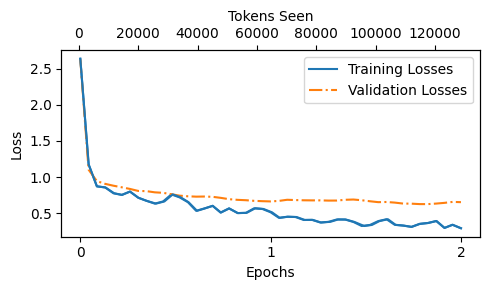

In [36]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## Extract and Save responses

In [37]:
torch.manual_seed(123)
for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud typically associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Prid

In [38]:
from tqdm import tqdm
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)

100%|█████████████████████████████████████████| 110/110 [02:18<00:00,  1.26s/it]


In [39]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as a bullet.'}


In [40]:
# Save trained model
import re
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


In [41]:
# Can load model via:
# model.load_state_dict(torch.load("gpt2-medium355M-sft.pth"))

## Eval the model

In [42]:
import psutil
def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(["name"]):
        if process_name in proc.info["name"]:
            running = True
            break
    return running

ollama_running = check_if_running("ollama")
if not ollama_running:
    raise RuntimeError("Ollama not running. Launch ollama before proceeding.")
print("Ollama running:", check_if_running("ollama"))

Ollama running: True


In [43]:
import urllib.request
def query_model(prompt, model="llama3", url="http://localhost:11434/api/chat"):
    data = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "options": {
            "seed": 123,
            "temperature": 0,
            "num_ctx": 2048
        }
    }

    payload = json.dumps(data).encode("utf-8")
    request = urllib.request.Request(
    url,
    data=payload,
    method="POST"
    )
    
    request.add_header("Content-Type", "application/json")
    response_data = ""
    with urllib.request.urlopen(request) as response:
        while True:
            line = response.readline().decode("utf-8")
            if not line:
                break
            response_json = json.loads(line)
            response_data += response_json["message"]["content"]
    return response_data

In [44]:
model = "llama3"
result = query_model("What do Llamas eat?", model)
print(result)

Llamas are herbivores, which means they primarily feed on plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: High-quality hay, such as alfalfa or timothy hay, is a staple in a llama's diet. They enjoy munching on dry hay as a snack or as a supplement to their grazing.
3. Grains: Llamas may receive grains like oats, barley, or corn as part of their diet. However, it's essential to provide these grains in moderation, as they can be high in calories and low in fiber.
4. Fruits and vegetables: Llamas enjoy a variety of fruits and veggies, such as apples, carrots, sweet potatoes, and leafy greens like kale or spinach. These treats are great for providing essential vitamins and minerals.
5. Minerals: Llamas need access to mineral supplements, which can include salt, calcium, and phosphorus. These minerals help maintain their overall health and strong bones.

In the 

In [45]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a bullet.

Score:
>> I'd rate the model response "The car is as fast as a bullet." an 85 out of 100.

Here's why:

* The response uses a simile correctly, comparing the speed of the car to something else (in this case, a bullet).
* The comparison is relevant and makes sense, as bullets are known for their high velocity.
* The phrase "as fast as" is used correctly to introduce the simile.

The only reason I wouldn't give it a perfect score is that some people might find the comparison slightly less vivid or evocative than using lightning (which is often associated with speed and power). However, "a bullet" is still a strong and effective comparison that effectively conveys the idea of the car's speed.

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud typically associated with thund

In [46]:
def generate_model_scores(json_data, json_key, model="llama3"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue
    return scores

In [47]:
scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|████████████████████████| 110/110 [00:30<00:00,  3.64it/s]

Number of scores: 110 of 110
Average score: 47.95

